# TCR CDR3 Enrichment Analysis — abDMS Paired Chain
## Exploratory Data Analysis & Visualization

Analyzes paired α/β CDR3 TCR enrichment data from deep mutational scanning (abDMS).

| Property | Value |
|---|---|
| Dataset | P3620_LUCA-TCRDMF5-abDMS |
| Peptides | DRG01–04, GIG01–05 |
| Alpha CDR3 | 10 AA (positions a0–a9) |
| Beta CDR3 | 11 AA (positions b0–b10) |
| Enrichment metric | `enrich_pos1x_vs_neg` (positive / negative selection ratio) |

### Notebook outline
1. **EDA Overview** – per-peptide statistics and score distributions
2. **Residue Enrichment Heatmaps** – which residues at which positions are enriched per peptide
3. **Interactive Position Co-Enrichment Explorer** – which α/β position pairs jointly drive enrichment,
   with click-to-inspect residue distributions


## Requirements

Install all dependencies (from the project root):

```bash
pip install -r notebooks/requirements_eda.txt
```

For interactive widgets in **JupyterLab**:
```bash
jupyter labextension install @jupyter-widgets/jupyterlab-manager
```

For classic **Jupyter Notebook**:
```bash
jupyter nbextension enable --py widgetsnbextension
```


In [24]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})
print("All imports OK.")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | "
      f"seaborn {sns.__version__} | matplotlib {matplotlib.__version__}")


All imports OK.
  pandas 2.3.2 | numpy 2.0.2 | seaborn 0.13.2 | matplotlib 3.9.4


In [28]:
# ── Configuration ──────────────────────────────────────────────────────────
DATA_DIR = (
    '/cluster/project/reddy/marluca/NGS_pipeline/data/'
    'P3620_LUCA-TCRDMF5-abDMS/04_variant_labeling'
)

# Unified column names written into every loaded DataFrame
ENRICHMENT_COL = 'enrich_unified'   # enrichment ratio (positive / negative selection)
STATUS_COL     = 'status_unified'   # Enriched / Depleted / NoChange
LOG2_COL       = 'log2_enrich'      # derived log2 column
PSEUDOCOUNT    = 1e-9               # clip before log2 (avoids log(0))
MIN_COUNT      = 5                  # min variants per group for enrichment score

# Per-peptide source columns — override here if a peptide uses a different selection round
# GIG02 has a 2x selection round; use pos2x/neg2x for it, pos1x for everything else
PEPTIDE_ENRICH_COLS = {
    'GIG02': ('enrich_pos2x_vs_neg', 'pos2x_vs_neg_status'),
}
DEFAULT_ENRICH_COLS = ('enrich_pos1x_vs_neg', 'pos1x_vs_neg_status')

# Amino-acid ordering grouped by physicochemical class
AA_ORDER = list('GAVLIPFWM') + list('STCYNQ') + list('KRH') + list('DE')

STATUS_COLORS = {
    'Enriched':  '#2ecc71',
    'NoChange':  '#95a5a6',
    'Depleted':  '#e74c3c',
}
SPEC_COLORS = {0: '#e74c3c', 1: '#f39c12', 2: '#3498db'}

# ── Load all peptide CSVs ──────────────────────────────────────────────────
summary_meta = pd.read_csv(os.path.join(DATA_DIR, 'variant_labeling_summary.csv'))
PEPTIDES = summary_meta['peptide'].tolist()

dfs = []
for pep in PEPTIDES:
    fpath = os.path.join(DATA_DIR, f'{pep}.variant_labeling.csv')
    if not os.path.exists(fpath):
        print(f'WARNING: {fpath} not found, skipping.')
        continue
    d = pd.read_csv(fpath)
    enrich_src, status_src = PEPTIDE_ENRICH_COLS.get(pep, DEFAULT_ENRICH_COLS)
    d[ENRICHMENT_COL] = d[enrich_src]
    d[STATUS_COL]     = d[status_src]
    round_label = '2x' if pep in PEPTIDE_ENRICH_COLS else '1x'
    print(f"  {pep}: using {enrich_src} / {status_src}  [{round_label}]")
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
df[LOG2_COL] = np.log2(df[ENRICHMENT_COL].clip(lower=PSEUDOCOUNT))

df_enr = df[df[STATUS_COL] == 'Enriched'].copy()
df_dep = df[df[STATUS_COL] == 'Depleted'].copy()

ALPHA_LEN    = len(df['alpha_aa'].iloc[0])  # 10
BETA_LEN     = len(df['beta_aa'].iloc[0])   # 11
ALPHA_LABELS = [f'a{i}' for i in range(ALPHA_LEN)]
BETA_LABELS  = [f'b{i}' for i in range(BETA_LEN)]

print(f"\nLoaded {len(PEPTIDES)} peptides · {len(df):,} total variants")
print(f"  Alpha CDR3: {ALPHA_LEN} AA | Beta CDR3: {BETA_LEN} AA")
print(f"  Enriched: {len(df_enr):,} | Depleted: {len(df_dep):,} | "
      f"NoChange: {(df[STATUS_COL]=='NoChange').sum():,}")
print("\nSelection round per peptide:")
for pep in PEPTIDES:
    ec, sc = PEPTIDE_ENRICH_COLS.get(pep, DEFAULT_ENRICH_COLS)
    print(f"  {pep}: {ec}")


  DRG01: using enrich_pos1x_vs_neg / pos1x_vs_neg_status  [1x]
  DRG02: using enrich_pos1x_vs_neg / pos1x_vs_neg_status  [1x]
  DRG03: using enrich_pos1x_vs_neg / pos1x_vs_neg_status  [1x]
  DRG04: using enrich_pos1x_vs_neg / pos1x_vs_neg_status  [1x]
  GIG01: using enrich_pos1x_vs_neg / pos1x_vs_neg_status  [1x]
  GIG02: using enrich_pos2x_vs_neg / pos2x_vs_neg_status  [2x]
  GIG03: using enrich_pos1x_vs_neg / pos1x_vs_neg_status  [1x]
  GIG04: using enrich_pos1x_vs_neg / pos1x_vs_neg_status  [1x]
  GIG05: using enrich_pos1x_vs_neg / pos1x_vs_neg_status  [1x]

Loaded 9 peptides · 262,279 total variants
  Alpha CDR3: 10 AA | Beta CDR3: 11 AA
  Enriched: 43,877 | Depleted: 160,840 | NoChange: 57,562

Selection round per peptide:
  DRG01: enrich_pos1x_vs_neg
  DRG02: enrich_pos1x_vs_neg
  DRG03: enrich_pos1x_vs_neg
  DRG04: enrich_pos1x_vs_neg
  GIG01: enrich_pos1x_vs_neg
  GIG02: enrich_pos2x_vs_neg
  GIG03: enrich_pos1x_vs_neg
  GIG04: enrich_pos1x_vs_neg
  GIG05: enrich_pos1x_vs_neg


## 1 · EDA Overview

In [29]:
rows = []
for pep in PEPTIDES:
    d = df[df['peptide'] == pep]
    n    = len(d)
    n_e  = (d[STATUS_COL] == 'Enriched').sum()
    n_d  = (d[STATUS_COL] == 'Depleted').sum()
    n_nc = (d[STATUS_COL] == 'NoChange').sum()
    med_log2 = d.loc[d[STATUS_COL] == 'Enriched', LOG2_COL].median()
    ec, _    = PEPTIDE_ENRICH_COLS.get(pep, DEFAULT_ENRICH_COLS)
    sel_round = '2x' if pep in PEPTIDE_ENRICH_COLS else '1x'
    rows.append({
        'Peptide':             pep,
        'Selection round':     sel_round,
        'Enrichment source':   ec,
        'N total':             n,
        'N enriched':          n_e,
        'N depleted':          n_d,
        'N no-change':         n_nc,
        'Enrich rate (%)':     round(100 * n_e / n, 1),
        'Median log₂ enrich':  round(med_log2, 2),
    })

summary_df = pd.DataFrame(rows).set_index('Peptide')
display(
    summary_df.style
    .background_gradient(subset=['N enriched'], cmap='Greens')
    .background_gradient(subset=['Enrich rate (%)'], cmap='Blues')
    .format({'Median log₂ enrich': '{:.2f}', 'Enrich rate (%)': '{:.1f}'})
)


,Selection round,Enrichment source,N total,N enriched,N depleted,N no-change,Enrich rate (%),Median log₂ enrich
Peptide,,,,,,,,
DRG01,1x,enrich_pos1x_vs_neg,30899,4679,21080,5140,15.1,4.39
DRG02,1x,enrich_pos1x_vs_neg,26894,1121,20238,5535,4.2,4.99
DRG03,1x,enrich_pos1x_vs_neg,29244,1012,24073,4159,3.5,4.80
DRG04,1x,enrich_pos1x_vs_neg,30145,7487,15516,7142,24.8,13.60
GIG01,1x,enrich_pos1x_vs_neg,29183,8362,13504,7317,28.7,13.87
GIG02,2x,enrich_pos2x_vs_neg,30765,1127,22271,7367,3.7,5.13
GIG03,1x,enrich_pos1x_vs_neg,26616,4741,14711,7164,17.8,13.96
GIG04,1x,enrich_pos1x_vs_neg,29552,8484,14306,6762,28.7,13.86
GIG05,1x,enrich_pos1x_vs_neg,28981,6864,15141,6976,23.7,14.21


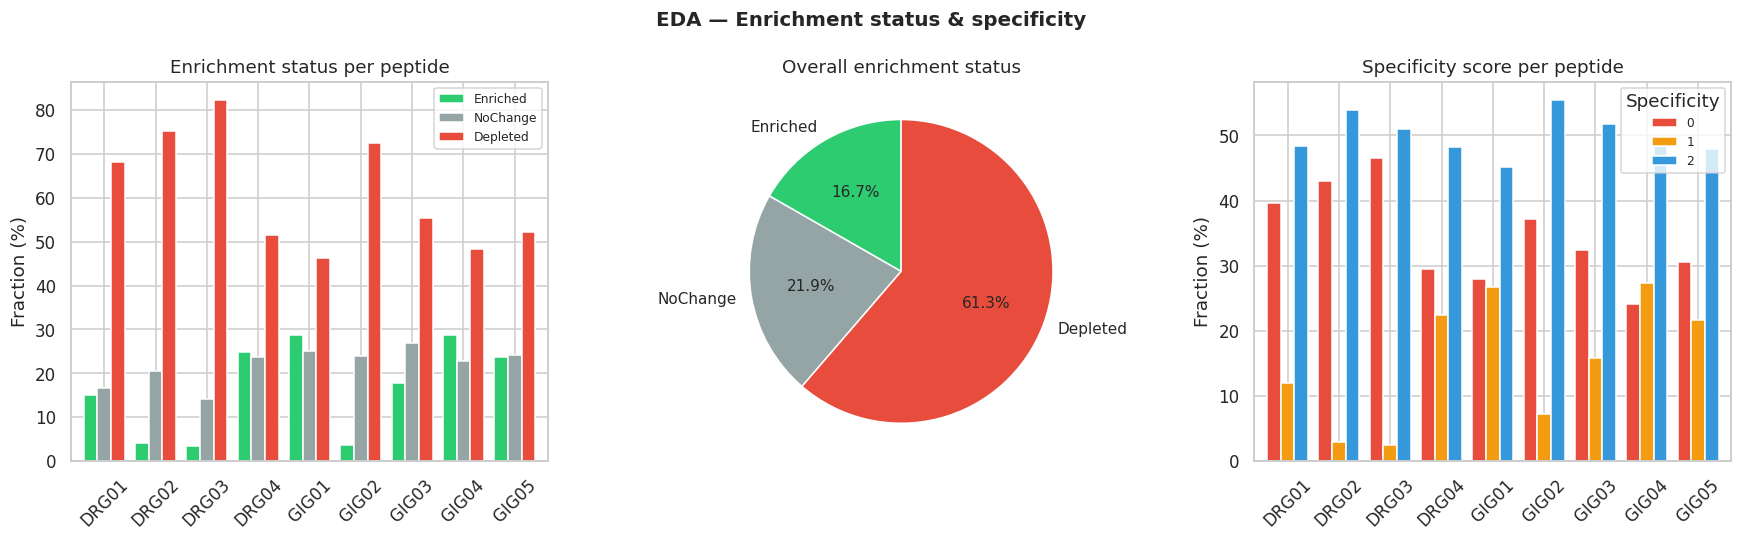

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# — stacked bar: enrichment status per peptide
pivot_status = (
    df.groupby(['peptide', STATUS_COL]).size()
    .unstack(fill_value=0)
    .reindex(PEPTIDES)
)
pct_status = pivot_status.div(pivot_status.sum(axis=1), axis=0) * 100
order = ['Enriched', 'NoChange', 'Depleted']
pct_status[order].plot(
    kind='bar', ax=axes[0],
    color=[STATUS_COLORS[s] for s in order],
    width=0.8, edgecolor='white', legend=True
)
axes[0].set_title('Enrichment status per peptide')
axes[0].set_ylabel('Fraction (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper right', fontsize=8)

# — overall pie
overall = df[STATUS_COL].value_counts().reindex(order)
axes[1].pie(
    overall.values, labels=order,
    colors=[STATUS_COLORS[s] for s in order],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10}
)
axes[1].set_title('Overall enrichment status')

# — specificity stacked bar
pivot_spec = (
    df.groupby(['peptide', 'specificity']).size()
    .unstack(fill_value=0)
    .reindex(PEPTIDES)
)
pct_spec = pivot_spec.div(pivot_spec.sum(axis=1), axis=0) * 100
pct_spec[[0, 1, 2]].plot(
    kind='bar', ax=axes[2],
    color=[SPEC_COLORS[i] for i in [0, 1, 2]],
    width=0.8, edgecolor='white', legend=True
)
axes[2].set_title('Specificity score per peptide')
axes[2].set_ylabel('Fraction (%)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Specificity', loc='upper right', fontsize=8)

plt.suptitle('EDA — Enrichment status & specificity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_status_distributions.pdf', bbox_inches='tight')
plt.show()


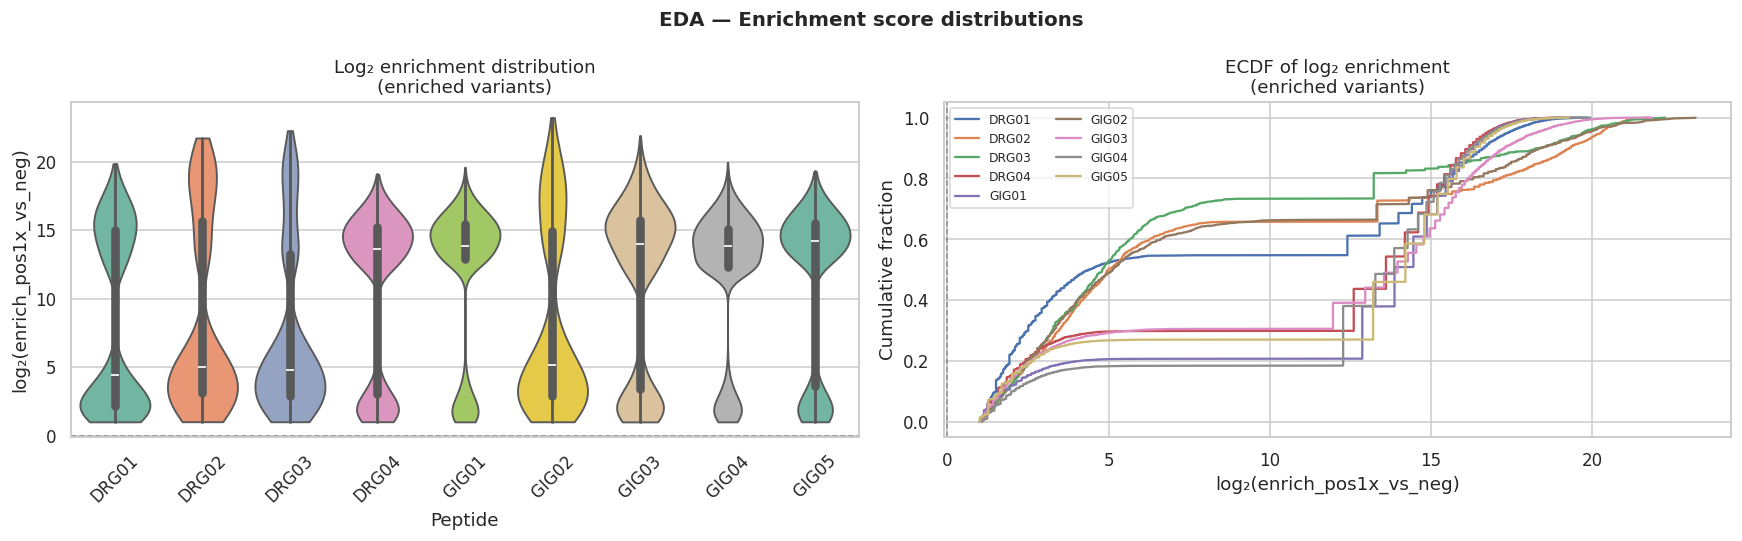

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Violin of log2 enrichment (enriched variants only)
sns.violinplot(
    data=df_enr, x='peptide', y=LOG2_COL, order=PEPTIDES,
    ax=axes[0], palette='Set2', cut=0, inner='box'
)
axes[0].axhline(0, color='k', ls='--', alpha=0.4, lw=1)
axes[0].set_title('Log₂ enrichment distribution\n(enriched variants)')
axes[0].set_xlabel('Peptide')
axes[0].set_ylabel('log₂(enrich_pos1x_vs_neg)')
axes[0].tick_params(axis='x', rotation=45)

# ECDF of log2 enrichment per peptide
for pep in PEPTIDES:
    d = df_enr[df_enr['peptide'] == pep][LOG2_COL].sort_values()
    ecdf = np.arange(1, len(d) + 1) / len(d)
    axes[1].plot(d.values, ecdf, label=pep, lw=1.5)
axes[1].set_xlabel('log₂(enrich_pos1x_vs_neg)')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('ECDF of log₂ enrichment\n(enriched variants)')
axes[1].legend(fontsize=8, ncol=2)
axes[1].axvline(0, color='k', ls='--', alpha=0.4, lw=1)

plt.suptitle('EDA — Enrichment score distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_enrichment_distributions.pdf', bbox_inches='tight')
plt.show()


## 2 · Residue Enrichment Heatmaps

For each peptide and chain (α / β), compute the **mean log₂ enrichment** across all variants
that carry a given amino acid at a given CDR3 position.

* **Rows** = amino acids (ordered by physicochemical class: nonpolar → polar → basic → acidic)
* **Columns** = CDR3 positions (a0–a9 for alpha, b0–b10 for beta)
* **Color** = mean log₂(enrich_pos1x_vs_neg); green = enriched, red = depleted

Positions with fewer than `MIN_COUNT` observed variants for a given AA are shown as white (NaN).


In [32]:
def residue_enrichment_matrix(df_sub, chain='alpha', score_col=LOG2_COL,
                               aa_order=AA_ORDER, min_count=MIN_COUNT):
    """
    Returns DataFrame (AA × position) with mean log₂ enrichment.
    Cells with fewer than min_count observations are NaN.
    """
    col = f'{chain}_aa'
    cdr3_len = len(df_sub[col].iloc[0])

    records = []
    for pos in range(cdr3_len):
        tmp = df_sub[[col, score_col]].copy()
        tmp['aa']  = tmp[col].str[pos]
        tmp['pos'] = pos
        records.append(tmp[['aa', 'pos', score_col]])

    long = pd.concat(records, ignore_index=True)
    grp  = long.groupby(['aa', 'pos'])[score_col].agg(['mean', 'count'])
    grp.loc[grp['count'] < min_count, 'mean'] = np.nan
    pivot = grp['mean'].unstack('pos')

    pivot = pivot.reindex([aa for aa in aa_order if aa in pivot.index])
    pivot.columns = [f'{chain[0]}{i}' for i in range(cdr3_len)]
    return pivot


def plot_residue_heatmaps_for_peptide(ax_alpha, ax_beta, df_pep, pep, wt_alpha, wt_beta, vmin=-8, vmax=8):
    """Draw alpha and beta residue enrichment heatmaps on provided axes."""
    cmap = matplotlib.colormaps.get_cmap('RdYlGn').copy()
    cmap.set_bad(color='#f0f0f0')   # NaN cells shown in light grey

    for ax, chain, wt_seq in zip([ax_alpha, ax_beta], ['alpha', 'beta'], [wt_alpha, wt_beta]):
        mat = residue_enrichment_matrix(df_pep, chain=chain)
        im = ax.imshow(mat.values, cmap=cmap, aspect='auto',
                       vmin=vmin, vmax=vmax,
                       interpolation='nearest')
        ax.set_xticks(range(mat.shape[1]))
        ax.set_xticklabels(mat.columns, fontsize=7)
        ax.set_yticks(range(mat.shape[0]))
        ax.set_yticklabels(mat.index, fontsize=7)
        ax.set_xlabel('CDR3 position', fontsize=8)
        ax.set_ylabel('Amino acid', fontsize=8)
        ax.set_title(f'{pep} — {chain.capitalize()} CDR3', fontsize=9, fontweight='bold')

        # Thin grid lines
        ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
        ax.grid(which='minor', color='#cccccc', linewidth=0.3)
        ax.tick_params(which='minor', length=0)

        # --- Highlight WT residues ---
        for pos, wt_aa in enumerate(wt_seq):
            if wt_aa in mat.index:
                y = mat.index.get_loc(wt_aa)
                rect = Rectangle(
                    (pos - 0.5, y - 0.5),  # bottom-left corner
                    1, 1,
                    fill=False,
                    edgecolor='black',
                    linewidth=1.5
                )
                ax.add_patch(rect)

        plt.colorbar(im, ax=ax, shrink=0.8, label='mean log₂ enrich')

print("Helper functions defined.")


Helper functions defined.


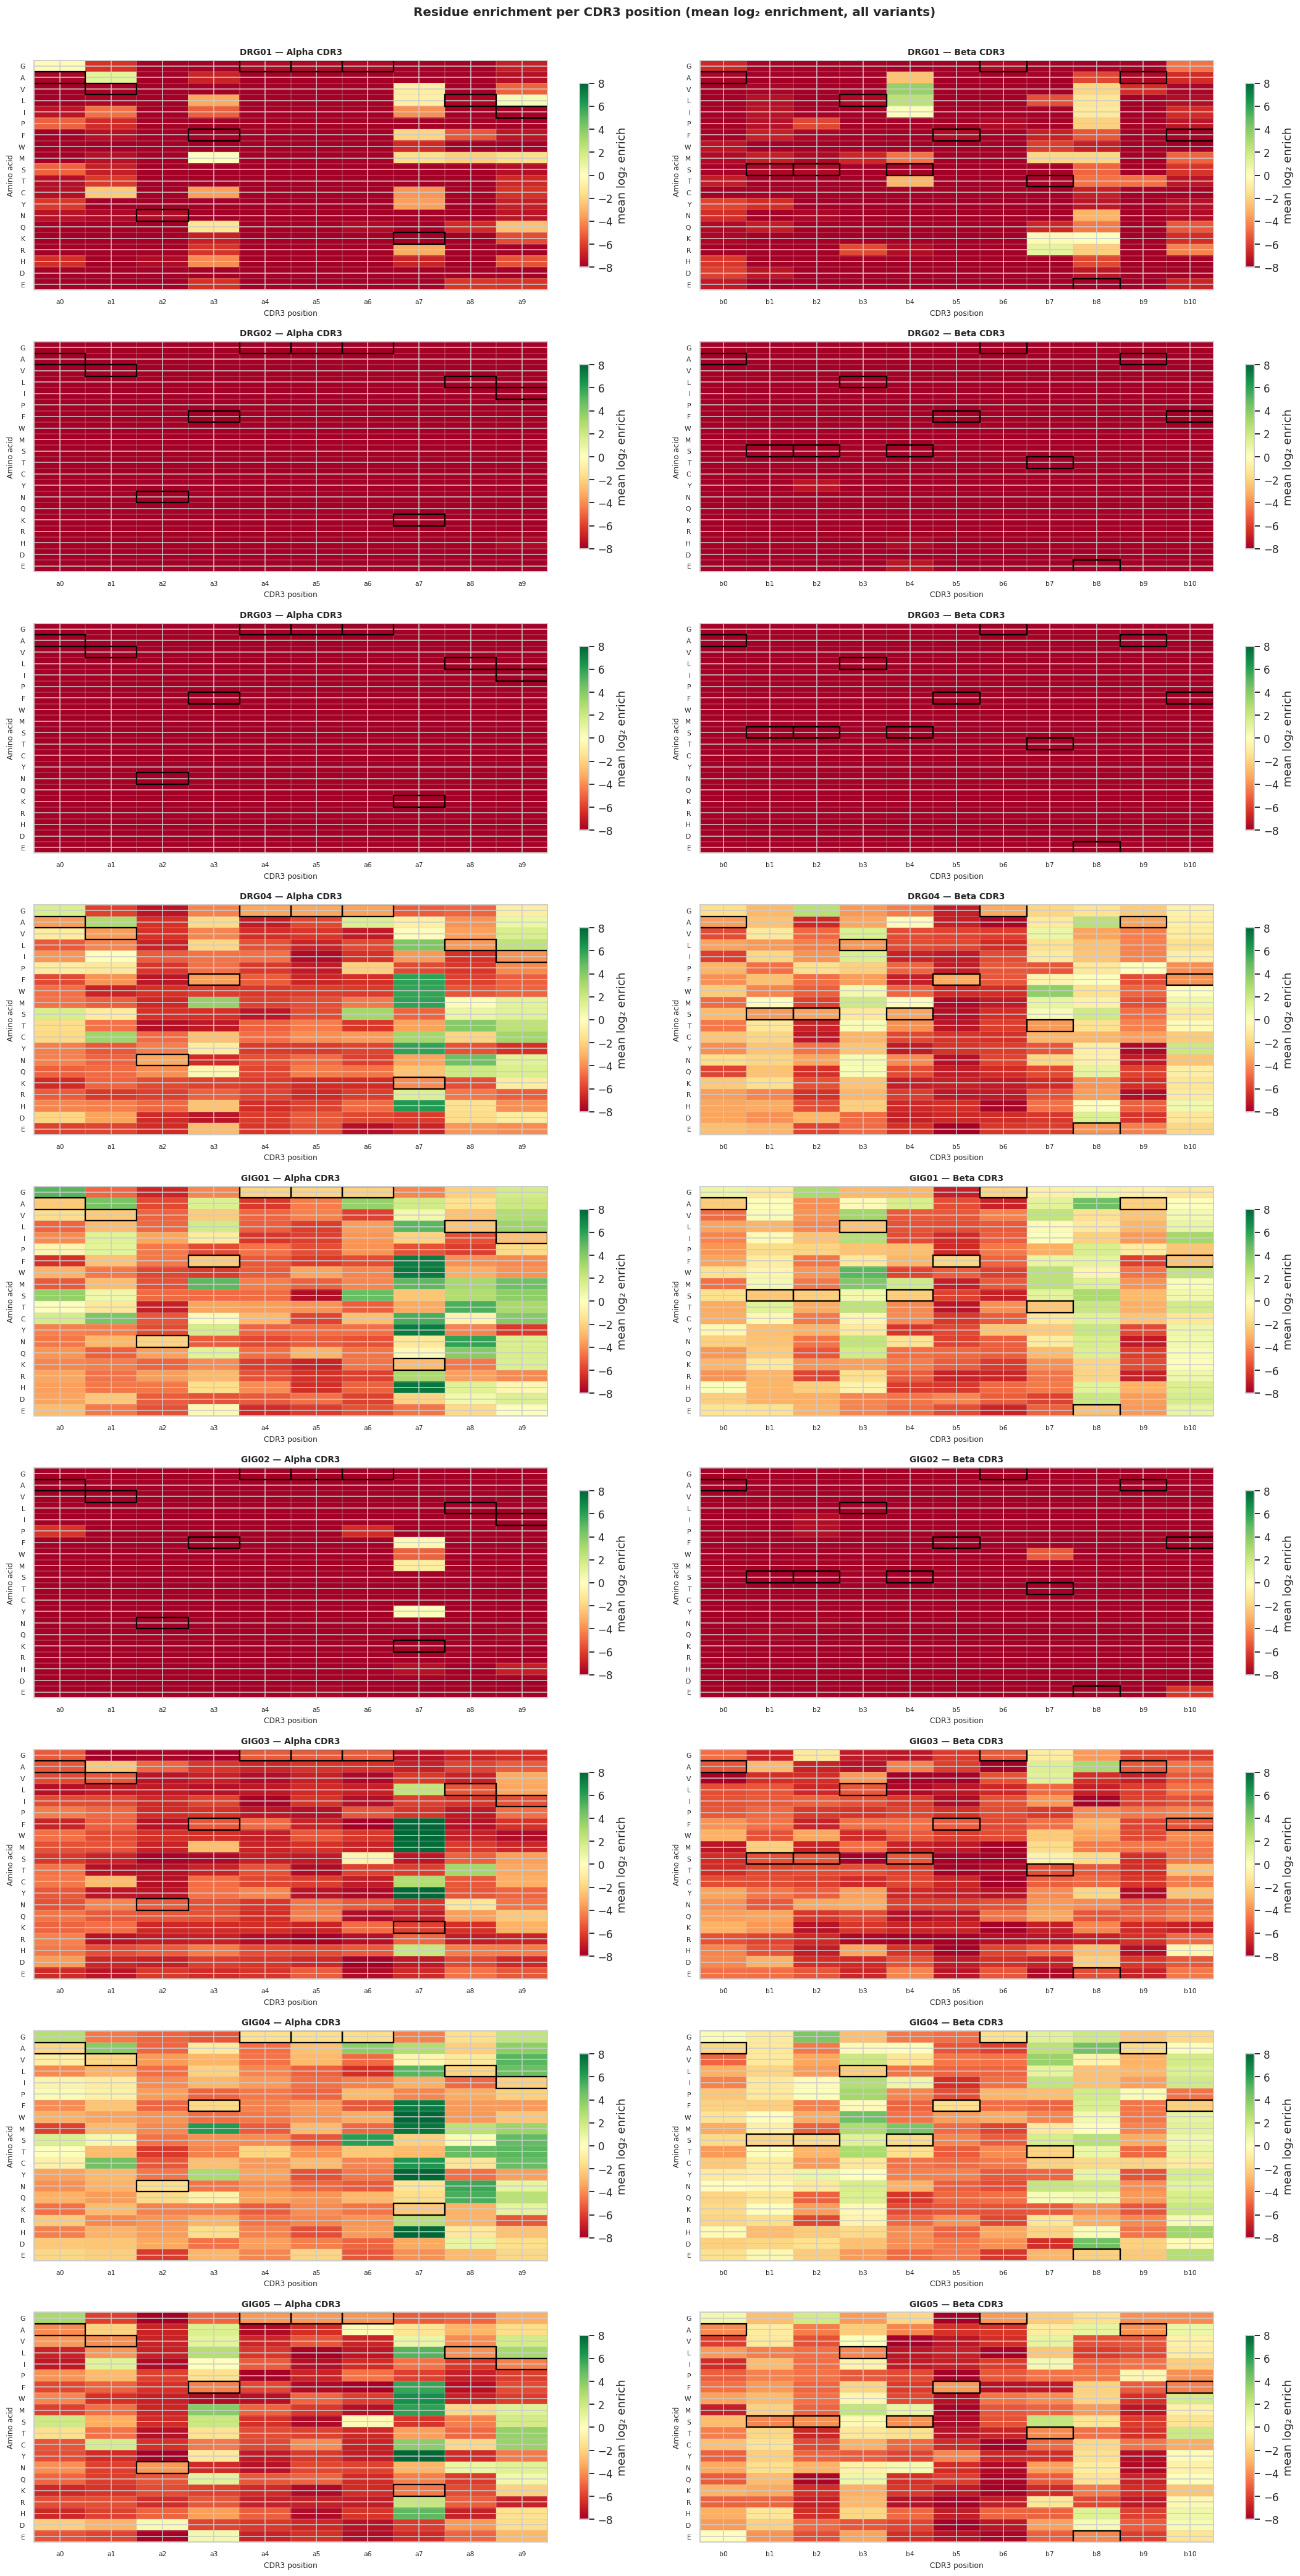

Saved → fig3_residue_enrichment_heatmaps.pdf


In [33]:
wt_alpha = 'AVNFGGGKLI'
wt_beta = 'ASSLSFGTEAF'

n_pep = len(PEPTIDES)
fig, axes = plt.subplots(n_pep, 2, figsize=(20, 4.2 * n_pep))

for i, pep in enumerate(PEPTIDES):
    df_pep = df[df['peptide'] == pep]
    plot_residue_heatmaps_for_peptide(axes[i, 0], axes[i, 1], df_pep, pep, wt_alpha, wt_beta)

plt.suptitle(
    'Residue enrichment per CDR3 position (mean log₂ enrichment, all variants)',
    fontsize=13, fontweight='bold', y=1.002
)
plt.tight_layout()
plt.savefig('fig3_residue_enrichment_heatmaps.pdf', bbox_inches='tight')
plt.show()
print("Saved → fig3_residue_enrichment_heatmaps.pdf")


## 3 · Interactive Position Co-Enrichment Explorer

### What is shown

**Main heatmap (top):**
For every pair of positions (α_i × β_j), the cell shows the **maximum enrichment rate boost**
achievable by specifying the best amino-acid pair at those two positions:

> cell value = max P(enriched | aa_α, aa_β) − P(enriched overall)

Positive values (green) → knowing the amino-acid pair at (α_i, β_j) increases enrichment
probability above baseline. Requires ≥ `MIN_COUNT` total variants per group.

**Detail plots (bottom):**
For the selected position pair, shows:
1. Per-residue enrichment rate `P(enriched | aa)` for each chain position (bars vs dashed baseline)
2. Amino-acid co-occurrence heatmap of **enriched variants** at that position pair

Use the **dropdown** to change peptide and the **sliders** to select positions.


In [ ]:
def compute_coenrichment_matrix(df_sub, min_count=MIN_COUNT):
    """
    Returns (ALPHA_LEN × BETA_LEN) array and the baseline enrichment rate.

    Cell (i, j) = max P(enriched | aa_α_i, aa_β_j) − baseline_rate,
    over all (aa_alpha, aa_beta) pairs with >= min_count total variants.

    Positive = the best amino-acid pair at those positions enriches above chance.
    """
    baseline = (df_sub[STATUS_COL] == 'Enriched').mean()
    is_enr   = (df_sub[STATUS_COL] == 'Enriched').astype(int)
    mat = np.full((ALPHA_LEN, BETA_LEN), np.nan)

    for ai in range(ALPHA_LEN):
        col_a = df_sub['alpha_aa'].str[ai]
        for bj in range(BETA_LEN):
            col_b  = df_sub['beta_aa'].str[bj]
            pair   = col_a + col_b
            tmp    = pd.DataFrame({'pair': pair, 'enr': is_enr})
            grp    = tmp.groupby('pair')['enr'].agg(['sum', 'count'])
            grp    = grp[grp['count'] >= min_count].copy()
            if len(grp):
                grp['rate'] = grp['sum'] / grp['count']
                mat[ai, bj] = grp['rate'].max() - baseline

    return mat, baseline


print("Computing co-enrichment matrices (may take ~1–2 min) …")
COENRICH   = {}   # peptide → (ALPHA × BETA) numpy array
BASELINES  = {}   # peptide → baseline enrichment rate
for pep in PEPTIDES:
    mat, bl = compute_coenrichment_matrix(df[df['peptide'] == pep])
    COENRICH[pep]  = mat
    BASELINES[pep] = bl
    print(f"  ✓ {pep}  (baseline={bl:.3f}, max_boost={np.nanmax(mat):.3f})")
print("Done.")


In [ ]:
# Quick static overview: one small heatmap per peptide
ncols = 3
nrows = int(np.ceil(len(PEPTIDES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
axes = axes.flatten()
all_vals = np.concatenate([m.flatten() for m in COENRICH.values()])
abs_max  = np.nanpercentile(np.abs(all_vals), 98)
cmap = matplotlib.colormaps.get_cmap('RdYlGn').copy()
cmap.set_bad('#f0f0f0')
for idx, pep in enumerate(PEPTIDES):
    ax  = axes[idx]
    mat = COENRICH[pep]
    im  = ax.imshow(mat, cmap=cmap, aspect='auto',
                    vmin=-abs_max, vmax=abs_max, interpolation='nearest')
    ax.set_xticks(range(BETA_LEN))
    ax.set_xticklabels(BETA_LABELS, fontsize=7)
    ax.set_yticks(range(ALPHA_LEN))
    ax.set_yticklabels(ALPHA_LABELS, fontsize=7)
    ax.set_xlabel('Beta position', fontsize=8)
    ax.set_ylabel('Alpha position', fontsize=8)
    bl = BASELINES[pep]
    ax.set_title(f'{pep}  (baseline={bl:.3f})', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.85, label='ΔP(enriched)')
for idx in range(len(PEPTIDES), len(axes)):
    axes[idx].set_visible(False)
plt.suptitle(
    'Position co-enrichment: max ΔP(enriched) per (α_pos × β_pos) pair'
    'Cell = best amino-acid pair enrichment rate minus peptide baseline',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('fig4_position_coenrichment_overview.pdf', bbox_inches='tight')
plt.show()
print("Saved → fig4_position_coenrichment_overview.pdf")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Interactive Position Co-Enrichment Explorer
# ─────────────────────────────────────────────────────────────────────────

cmap_heatmap = matplotlib.colormaps.get_cmap('RdYlGn').copy()
cmap_heatmap.set_bad('#f0f0f0')

# Widgets
pep_dd   = widgets.Dropdown(options=PEPTIDES, value=PEPTIDES[0],
                            description='Peptide:', layout=widgets.Layout(width='200px'))
a_slider = widgets.IntSlider(value=0, min=0, max=ALPHA_LEN - 1,
                             description='α position:', style={'description_width': 'initial'})
b_slider = widgets.IntSlider(value=0, min=0, max=BETA_LEN - 1,
                             description='β position:', style={'description_width': 'initial'})

main_out   = widgets.Output()
detail_out = widgets.Output()


def draw_main(pep):
    """Re-draw the co-enrichment heatmap for the selected peptide."""
    mat     = COENRICH[pep]
    abs_max = np.nanpercentile(np.abs(mat), 98)

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(mat, cmap=cmap_heatmap, aspect='auto',
                   vmin=-abs_max, vmax=abs_max, interpolation='nearest')

    # Annotate each cell with its value
    for ai in range(ALPHA_LEN):
        for bj in range(BETA_LEN):
            v = mat[ai, bj]
            if not np.isnan(v):
                ax.text(bj, ai, f'{v:.2f}', ha='center', va='center',
                        fontsize=6, color='black' if abs(v) < abs_max * 0.6 else 'white')

    # Mark currently selected cell
    ai = a_slider.value
    bj = b_slider.value
    rect = plt.Rectangle((bj - 0.5, ai - 0.5), 1, 1,
                          linewidth=2.5, edgecolor='navy', facecolor='none')
    ax.add_patch(rect)

    ax.set_xticks(range(BETA_LEN));  ax.set_xticklabels(BETA_LABELS, fontsize=9)
    ax.set_yticks(range(ALPHA_LEN)); ax.set_yticklabels(ALPHA_LABELS, fontsize=9)
    ax.set_xlabel('Beta CDR3 position', fontsize=11)
    ax.set_ylabel('Alpha CDR3 position', fontsize=11)
    bl = BASELINES[pep]
    ax.set_title(
        f'{pep}  (baseline enrichment rate: {bl:.3f})\n'
        f'Cell = max ΔP(enriched) for best (aa_α, aa_β) pair at that position',
        fontsize=11, fontweight='bold'
    )
    plt.colorbar(im, ax=ax, label='ΔP(enriched) above baseline', shrink=0.85)
    plt.tight_layout()

    with main_out:
        clear_output(wait=True)
        plt.show()


def draw_detail(pep, ai, bj):
    """Show per-residue enrichment rate and co-occurrence for selected positions."""
    d_pep = df[df['peptide'] == pep]
    d_enr = df_enr[df_enr['peptide'] == pep]

    # Enrichment rate per residue at alpha position ai
    all_a   = d_pep['alpha_aa'].str[ai].value_counts()
    enr_a   = d_enr['alpha_aa'].str[ai].value_counts()
    rate_a  = (enr_a / all_a).dropna().sort_index()

    # Enrichment rate per residue at beta position bj
    all_b   = d_pep['beta_aa'].str[bj].value_counts()
    enr_b   = d_enr['beta_aa'].str[bj].value_counts()
    rate_b  = (enr_b / all_b).dropna().sort_index()

    # Co-occurrence heatmap for enriched variants
    aa_a = d_enr['alpha_aa'].str[ai]
    aa_b = d_enr['beta_aa'].str[bj]
    cooc = pd.crosstab(aa_a, aa_b)
    cooc = cooc.reindex(
        index=[a for a in AA_ORDER if a in cooc.index],
        columns=[b for b in AA_ORDER if b in cooc.columns],
        fill_value=0
    )

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
    ax_a  = fig.add_subplot(gs[0, 0])
    ax_b  = fig.add_subplot(gs[0, 1])
    ax_co = fig.add_subplot(gs[1, :])

    # — Alpha residue enrichment rate
    ax_a.bar(range(len(rate_a)), rate_a.values, color='#3498db', edgecolor='white')
    ax_a.set_xticks(range(len(rate_a)))
    ax_a.set_xticklabels(rate_a.index, fontsize=9)
    ax_a.set_ylabel('P(enriched | aa)', fontsize=10)
    ax_a.set_xlabel('Amino acid', fontsize=10)
    ax_a.set_title(f'Alpha {ALPHA_LABELS[ai]}  —  per-residue enrichment rate\n({pep})',
                   fontsize=10, fontweight='bold')
    baseline = len(d_enr) / len(d_pep)
    ax_a.axhline(baseline, color='#e74c3c', ls='--', lw=1.5, label=f'baseline ({baseline:.3f})')
    ax_a.legend(fontsize=8)

    # — Beta residue enrichment rate
    ax_b.bar(range(len(rate_b)), rate_b.values, color='#e74c3c', edgecolor='white')
    ax_b.set_xticks(range(len(rate_b)))
    ax_b.set_xticklabels(rate_b.index, fontsize=9)
    ax_b.set_ylabel('P(enriched | aa)', fontsize=10)
    ax_b.set_xlabel('Amino acid', fontsize=10)
    ax_b.set_title(f'Beta {BETA_LABELS[bj]}  —  per-residue enrichment rate\n({pep})',
                   fontsize=10, fontweight='bold')
    ax_b.axhline(baseline, color='#3498db', ls='--', lw=1.5, label=f'baseline ({baseline:.3f})')
    ax_b.legend(fontsize=8)

    # — Co-occurrence heatmap
    if not cooc.empty:
        sns.heatmap(cooc, ax=ax_co, cmap='Blues', annot=True, fmt='d',
                    linewidths=0.4, cbar_kws={'label': '# enriched variants'})
        ax_co.set_title(
            f'Enriched variant co-occurrence at {ALPHA_LABELS[ai]} × {BETA_LABELS[bj]}  ({pep})\n'
            f'Row = α residue at {ALPHA_LABELS[ai]}, Col = β residue at {BETA_LABELS[bj]}',
            fontsize=10, fontweight='bold'
        )
        ax_co.set_xlabel(f'Beta {BETA_LABELS[bj]}', fontsize=10)
        ax_co.set_ylabel(f'Alpha {ALPHA_LABELS[ai]}', fontsize=10)
    else:
        ax_co.text(0.5, 0.5, 'No co-occurrence data', ha='center', va='center',
                   transform=ax_co.transAxes, fontsize=12)

    with detail_out:
        clear_output(wait=True)
        plt.show()


def on_change(change):
    pep = pep_dd.value
    ai  = a_slider.value
    bj  = b_slider.value
    draw_main(pep)
    draw_detail(pep, ai, bj)


pep_dd.observe(on_change,   names='value')
a_slider.observe(on_change, names='value')
b_slider.observe(on_change, names='value')

# Initial draw
draw_main(pep_dd.value)
draw_detail(pep_dd.value, a_slider.value, b_slider.value)

display(widgets.VBox([
    widgets.HBox([pep_dd]),
    main_out,
    widgets.HTML('<hr><h3 style="margin-top:10px">Position detail explorer</h3>'),
    widgets.HBox([a_slider, b_slider]),
    detail_out,
]))


## 4 · Top Enriched Position Pairs per Peptide

In [ ]:
def top_coenrich_pairs(pep, n=10):
    """Return a DataFrame with the top N (α_pos, β_pos) pairs by enrichment boost."""
    mat = COENRICH[pep]
    bl  = BASELINES[pep]
    rows = []
    for ai in range(ALPHA_LEN):
        for bj in range(BETA_LEN):
            if not np.isnan(mat[ai, bj]):
                rows.append({
                    'α position':        ALPHA_LABELS[ai],
                    'β position':        BETA_LABELS[bj],
                    'ΔP(enriched)':      round(mat[ai, bj], 4),
                    'Max enrich rate':   round(mat[ai, bj] + bl, 4),
                })
    return (pd.DataFrame(rows)
            .sort_values('ΔP(enriched)', ascending=False)
            .head(n)
            .reset_index(drop=True))

# Show for each peptide
for pep in PEPTIDES:
    print(f"\n{'━'*40}  {pep}")
    display(top_coenrich_pairs(pep).style.background_gradient(
        subset=['ΔP(enriched)', 'Max enrich rate'], cmap='Greens'))
